# Tutorial 10 | Koopman spectral backend on Paul15 hematopoiesis

Demonstrates the **Koopman** archetype backend on the same Paul15 dataset
used in tutorial 01, and shows how its output complements the default
semi-NMF decomposition.

| Step | Call | Output |
|------|------|--------|
| Preprocess | `sjd.pp.prepare_trajectory` | normalized adata + pseudotime |
| Fit (semi-NMF) | `sjd.tl.fit_drift(..., archetype_method='snmf')` | signed patterns + non-negative activations |
| Fit (Koopman)  | `sjd.tl.fit_drift(..., archetype_method='koopman', ...)` | Koopman modes + eigenvalues + growth / oscillation rates |
| Spectrum + Nyquist | `koopman.freqs` vs `koopman.nyquist_ang_freq` | frequency-vs-branch-limit overlay |
| Geometry | `koopman.geometry` (henrici, reactivity, transient_gain, eigvec_cond) | branch-free non-normality diagnostics |
| Metric choice | `whiten=False` vs `whiten=True` | how the reduced-space metric shapes geometry |
| Compare | activations, spectra, instability genes | side-by-side vs semi-NMF |

The Koopman backend fits a windowed linear operator on the vectorised
Jacobian sequence — the *same* Jacobian tensor that semi-NMF factorises
— and reports its eigenvalues as continuous-time growth / decay rates
and candidate oscillation frequencies. It slots into the same
`adata.uns['scjdo']` schema, so all downstream code (`get_instability_genes`,
`infer_regulators`, `sjd.pl.*`) keeps working.

For the underlying math and caveats see [`../KOOPMAN.md`](../KOOPMAN.md).


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import scjdo as sjd

# ── Configuration ──────────────────────────────────────────────────────────
N_ARCHETYPES = 5
N_EPOCHS     = 5000     # increase to 50,000 + GPU for publication quality
OUTDIR       = 'results/10_koopman/'
os.makedirs(OUTDIR, exist_ok=True)

print(f'scjdo v{sjd.__version__}')


scjdo v0.3.0


## 1. Load and preprocess Paul15

In [2]:
adata = sc.datasets.paul15()

# Same preprocessing as tutorial 01: drop lymphoid and DC (secondary lineages)
# and ribosomal genes so semi-NMF and Koopman see the same input.
REMOVE_CLUSTERS = ['19Lymph', '11DC']
adata = adata[~adata.obs['paul15_clusters'].isin(REMOVE_CLUSTERS)].copy()
ribo_mask = adata.var_names.str.startswith(('Rps', 'Rpl', 'RPS', 'RPL'))
adata = adata[:, ~ribo_mask].copy()

sjd.pp.prepare_trajectory(
    adata,
    groupby='paul15_clusters',
    root='7MEP',
    n_hvg=2000,
    n_pcs=50,
)
print(adata)
print(f"Pseudotime range: [{adata.obs['pseudotime'].min():.3f}, "
      f"{adata.obs['pseudotime'].max():.3f}]")


[pseudotime] DPT: root=7MEP, range=[0, 1]
AnnData object with n_obs × n_vars = 2669 × 2000
    obs: 'paul15_clusters', 'dpt_pseudotime', 'pseudotime'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'iroot', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'diffmap_evals', 'scjdo_prep'
    obsm: 'X_pca', 'X_latent', 'X_umap', 'X_diffmap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'
Pseudotime range: [0.000, 1.000]


## 2. Fit the drift field twice — semi-NMF and Koopman

Both calls share the *same* drift field training and Jacobian tensor;
they differ only in how that tensor is decomposed. Storing under
different keys lets us compare them side-by-side.


In [3]:
# ── Backend A: semi-NMF (default, sparse non-negative programs) ──────────
sjd.tl.fit_drift(
    adata,
    time_key='pseudotime',
    n_archetypes=N_ARCHETYPES,
    n_epochs=N_EPOCHS,
    vel_scale=2.0,
    archetype_method='snmf',
    key_added='scjdo_snmf',
    verbose=False,
)
print(f"[snmf]    R² = {adata.uns['scjdo_snmf']['r2']:.3f}")


/Users/terooatt/miniconda3/envs/scJDO/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/terooatt/miniconda3/envs/scJDO/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


[snmf]    R² = 1.000


In [4]:
# ── Backend B: windowed local Koopman (spectral lens) ────────────────────
# window_half sets the local operator support: 2*window_half+1 grid steps.
# ridge stabilises the reduced least-squares solve.
sjd.tl.fit_drift(
    adata,
    time_key='pseudotime',
    n_archetypes=N_ARCHETYPES,
    n_epochs=N_EPOCHS,
    vel_scale=2.0,
    archetype_method='koopman',
    koopman_kwargs=dict(mode='local', window_half=8, ridge=1e-4),
    key_added='scjdo_koop',
    verbose=False,
)
print(f"[koopman] R² = {adata.uns['scjdo_koop']['r2']:.3f}")
print('koopman diagnostics keys:',
      sorted(adata.uns['scjdo_koop']['koopman'].keys()))


[koopman] R² = 0.000
koopman diagnostics keys: ['delta_tau', 'dt_seq', 'eigenvalues', 'freqs', 'geometry', 'growth_rates', 'mode', 'nyquist_ang_freq', 'nyquist_cycle_freq', 'reduced_rank', 'ref_eigenvalues', 'singular_values', 'whiten', 'window_half']


## 3. Inspect the Koopman spectrum

The reference operator's eigenvalues on the complex plane summarise the
average dynamics of the pseudotime-ordered Jacobian sequence.

- Points **inside** the unit circle → decaying modes.
- Points **on** the unit circle → neutrally stable / oscillatory modes.
- Points **outside** the unit circle → growing modes (local instability).

Continuous-time rates are `μ = log(λ) / Δτ`, split into growth
(`Re μ`) and oscillation (`|Im μ|`).


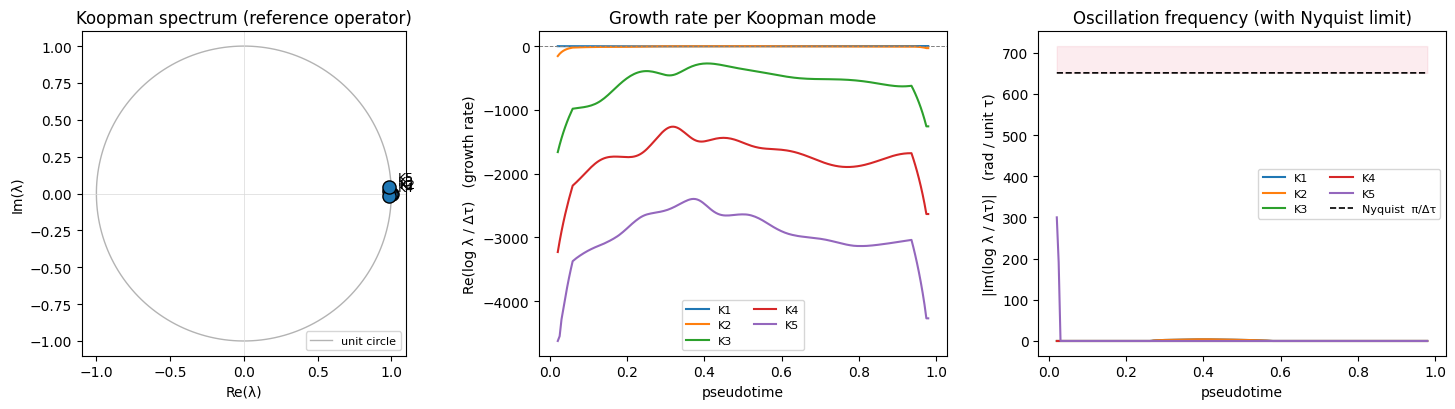

0.0% of (t, k) freq estimates are within 10% of the Nyquist bound — treat those as aliased, not real oscillations.


In [5]:
koop = adata.uns['scjdo_koop']['koopman']
lam_ref = np.asarray(koop['ref_eigenvalues'])         # (K,) complex
growth  = np.asarray(koop['growth_rates'])            # (T, K)
freqs   = np.asarray(koop['freqs'])                   # (T, K)
nyq_ang = np.asarray(koop['nyquist_ang_freq'])        # (T,) π/Δτ, rad/unit-τ
t_centers = np.asarray(adata.uns['scjdo_koop']['t_centers'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# ── (a) Reference eigenvalues on the complex plane ────────────────────────
theta = np.linspace(0, 2 * np.pi, 200)
axes[0].plot(np.cos(theta), np.sin(theta), color='0.7', lw=1, label='unit circle')
axes[0].scatter(lam_ref.real, lam_ref.imag, s=90, c='#1f77b4', edgecolor='k', zorder=3)
for k, l in enumerate(lam_ref):
    axes[0].annotate(f'K{k+1}', (l.real, l.imag),
                     textcoords='offset points', xytext=(6, 4), fontsize=9)
axes[0].axhline(0, color='0.85', lw=0.5); axes[0].axvline(0, color='0.85', lw=0.5)
axes[0].set_xlabel('Re(λ)'); axes[0].set_ylabel('Im(λ)')
axes[0].set_title('Koopman spectrum (reference operator)')
axes[0].set_aspect('equal', adjustable='box')
axes[0].legend(loc='lower right', fontsize=8)

# ── (b) Per-time continuous growth rate Re(μ_k(τ)) ───────────────────────
for k in range(growth.shape[1]):
    axes[1].plot(t_centers, growth[:, k], lw=1.5, label=f'K{k+1}')
axes[1].axhline(0, color='0.5', lw=0.7, linestyle='--')
axes[1].set_xlabel('pseudotime')
axes[1].set_ylabel('Re(log λ / Δτ)   (growth rate)')
axes[1].set_title('Growth rate per Koopman mode')
axes[1].legend(fontsize=8, ncol=2, loc='best')

# ── (c) Per-time candidate oscillation frequency |Im(μ_k(τ))| ────────────
# Overlay the per-window Nyquist limit π/Δτ. `freqs` values sitting above
# the shaded band are aliased, not measured — see KOOPMAN.md §5.
for k in range(freqs.shape[1]):
    axes[2].plot(t_centers, freqs[:, k], lw=1.5, label=f'K{k+1}')
axes[2].plot(t_centers, nyq_ang, color='k', lw=1.2, linestyle='--',
             label='Nyquist  π/Δτ')
axes[2].fill_between(t_centers, nyq_ang, nyq_ang * 1.1,
                     color='crimson', alpha=0.08)
axes[2].set_xlabel('pseudotime')
axes[2].set_ylabel('|Im(log λ / Δτ)|   (rad / unit τ)')
axes[2].set_title('Oscillation frequency (with Nyquist limit)')
axes[2].legend(fontsize=8, ncol=2, loc='best')

plt.tight_layout()
plt.savefig(OUTDIR + 'koopman_spectrum.pdf', bbox_inches='tight')
plt.show()

# Quick sanity check: how many (t, k) pairs report frequencies at/near
# the Nyquist bound? Those are the ones the branch ambiguity flags as
# not-really-measured.
near_bound = (freqs >= 0.9 * nyq_ang[:, None]).mean() * 100
print(f'{near_bound:.1f}% of (t, k) freq estimates are within 10% of the '
      f'Nyquist bound — treat those as aliased, not real oscillations.')


### Reading the plots

- Modes far outside the unit circle in (a) are the ones flagged as
  fast-growing on the sensitivity axis of (b).
- Modes near the unit circle with non-zero angle carry oscillation
  content in (c). In snapshot scRNA-seq these are *candidate*
  oscillations — the data cannot unambiguously identify true cycles,
  see the "Failure modes" section of `KOOPMAN.md`.
- The dashed line in (c) is the **Nyquist limit** π/Δτ. Frequencies at
  or above it are aliased — the principal branch of log has folded
  higher-frequency content into the identifiable band. Growth in (b)
  is not subject to this branch ambiguity.
- Curves near the pseudotime boundaries (τ ≈ 0 or τ ≈ 1) are less
  reliable — spectral pollution from short windows. Guard reported
  peaks with `sjd.tl.peak_interior`.


## 4. Branch-free geometry descriptors

The Koopman diagnostics also carry four descriptors computed **directly
on the discrete-time operator** K, without taking a logarithm — so they
are *immune to the Nyquist branch ambiguity* that constrains the
frequency estimate. In the snapshot-scRNA-seq setting where Δτ is
coarse relative to the fastest true dynamics, these tend to be the
better-posed half of the output.

| Descriptor | Reads as |
|---|---|
| `henrici`        | departure from normality (0 = normal K, 1 = maximally non-normal) |
| `reactivity`     | σ_max(K) / ρ(K); ≥ 1, tight iff K is normal — one-step amplification vs asymptotic rate |
| `transient_gain` | max_n ‖K^n‖₂ over n ≤ 30; short-horizon amplification that eigenvalues can miss |
| `eigvec_cond`    | κ(V); large when K is nearly defective — warns the eigen picture is fragile |

Non-normal windows are where "eigenvalues look boring but the operator
still amplifies stuff transiently" — worth flagging even when nothing
in the eigenvalue plot pops.


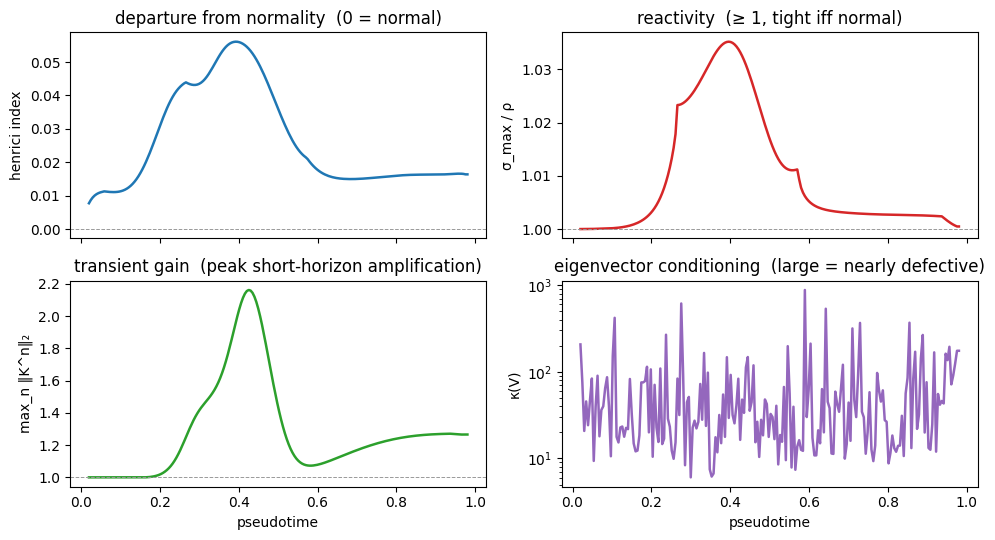

Reactive-burst candidate windows (low λ_max, high non-normality): 0 of 200


In [6]:
geom = adata.uns['scjdo_koop']['koopman']['geometry']

fig, axes = plt.subplots(2, 2, figsize=(10, 5.5), sharex=True)
axes[0, 0].plot(t_centers, geom['henrici'],        color='#1f77b4', lw=1.8)
axes[0, 0].axhline(0, color='0.6', lw=0.7, linestyle='--')
axes[0, 0].set_ylabel('henrici index')
axes[0, 0].set_title('departure from normality  (0 = normal)')

axes[0, 1].plot(t_centers, geom['reactivity'],     color='#d62728', lw=1.8)
axes[0, 1].axhline(1.0, color='0.6', lw=0.7, linestyle='--')
axes[0, 1].set_ylabel('σ_max / ρ')
axes[0, 1].set_title('reactivity  (≥ 1, tight iff normal)')

axes[1, 0].plot(t_centers, geom['transient_gain'], color='#2ca02c', lw=1.8)
axes[1, 0].axhline(1.0, color='0.6', lw=0.7, linestyle='--')
axes[1, 0].set_xlabel('pseudotime')
axes[1, 0].set_ylabel('max_n ‖K^n‖₂')
axes[1, 0].set_title('transient gain  (peak short-horizon amplification)')

axes[1, 1].plot(t_centers, geom['eigvec_cond'],    color='#9467bd', lw=1.8)
axes[1, 1].set_xlabel('pseudotime')
axes[1, 1].set_ylabel('κ(V)')
axes[1, 1].set_title('eigenvector conditioning  (large = nearly defective)')
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.savefig(OUTDIR + 'koopman_geometry.pdf', bbox_inches='tight')
plt.show()

# Which pseudotime windows report both a modest eigenvalue picture AND
# strong non-normality? Those are candidates for "reactive burst"
# behaviour that the growth-rate plot alone would miss.
lam_max_re  = np.asarray(adata.uns['scjdo_koop']['max_real_eig'])
non_normal  = np.asarray(geom['henrici'])
reactive_t  = t_centers[(lam_max_re < np.median(lam_max_re)) &
                        (non_normal > np.quantile(non_normal, 0.9))]
print(f'Reactive-burst candidate windows (low λ_max, high non-normality): '
      f'{len(reactive_t)} of {len(t_centers)}')


## 5. Metric choice — whitened vs shipped reduced-space geometry

The reduced trajectory `Z = Y V_r = U_r Σ_r` carries the singular-value
scaling: directions with larger σ dominate the least-squares fit and
shape the eigenvector geometry. `whiten=True` orthonormalises the
trajectory (`Z = U_r`) so the fit is balanced across modes. Under exact
LS the two operators are similar (same eigenvalues); with `ridge > 0`
they differ slightly on eigenvalues too. Every geometry descriptor
above depends on this choice — the paired output below makes the
sensitivity concrete.


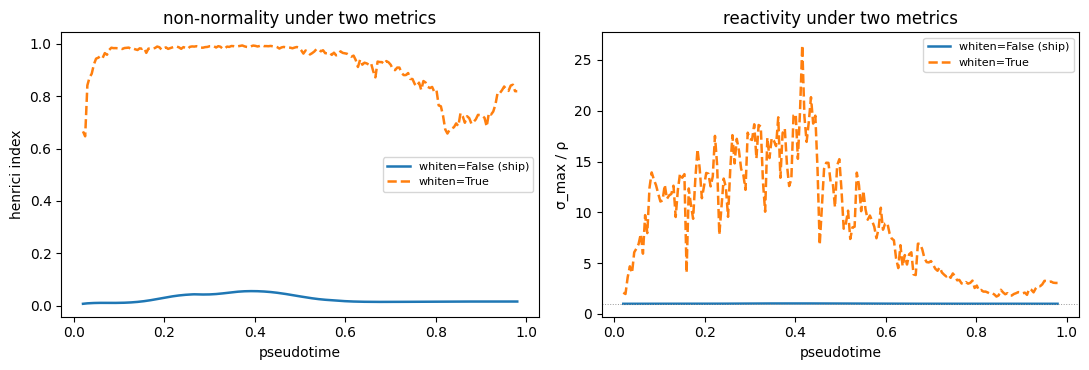

[ship]    whiten = False
[whiten]  whiten = True


In [7]:
sjd.tl.fit_drift(
    adata,
    time_key='pseudotime',
    n_archetypes=N_ARCHETYPES,
    n_epochs=N_EPOCHS,
    vel_scale=2.0,
    archetype_method='koopman',
    koopman_kwargs=dict(mode='local', window_half=8, ridge=1e-4, whiten=True),
    key_added='scjdo_koop_whiten',
    verbose=False,
)

geom_ship  = adata.uns['scjdo_koop']['koopman']['geometry']
geom_white = adata.uns['scjdo_koop_whiten']['koopman']['geometry']
t_ship  = adata.uns['scjdo_koop']['t_centers']
t_white = adata.uns['scjdo_koop_whiten']['t_centers']

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=False)
axes[0].plot(t_ship,  geom_ship['henrici'],  label='whiten=False (ship)', lw=1.8)
axes[0].plot(t_white, geom_white['henrici'], label='whiten=True',         lw=1.8, linestyle='--')
axes[0].set_xlabel('pseudotime'); axes[0].set_ylabel('henrici index')
axes[0].set_title('non-normality under two metrics')
axes[0].legend(fontsize=8)

axes[1].plot(t_ship,  geom_ship['reactivity'],  label='whiten=False (ship)', lw=1.8)
axes[1].plot(t_white, geom_white['reactivity'], label='whiten=True',         lw=1.8, linestyle='--')
axes[1].axhline(1.0, color='0.6', lw=0.7, linestyle=':')
axes[1].set_xlabel('pseudotime'); axes[1].set_ylabel('σ_max / ρ')
axes[1].set_title('reactivity under two metrics')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTDIR + 'koopman_metric_compare.pdf', bbox_inches='tight')
plt.show()

# Always record which metric produced the numbers you're reporting.
print(f"[ship]    whiten = {adata.uns['scjdo_koop']['koopman']['whiten']}")
print(f"[whiten]  whiten = {adata.uns['scjdo_koop_whiten']['koopman']['whiten']}")


## 6. Compare activation profiles — semi-NMF vs Koopman

Both backends return `(T, K)` non-negative activation arrays that can be
compared directly. Semi-NMF activations read as "which regulatory
program is active"; Koopman activations `|b_k(τ)|` read as "how much
does the trajectory currently project onto mode k".


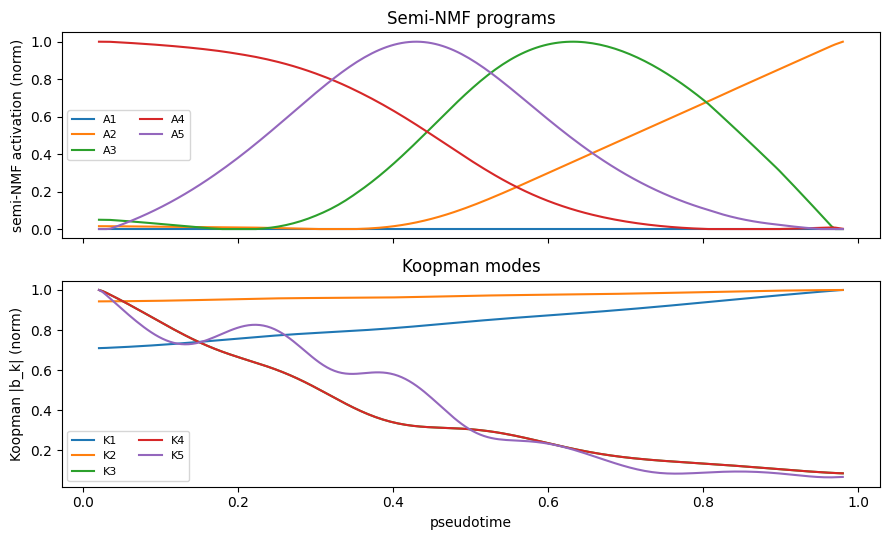

In [8]:
snmf = adata.uns['scjdo_snmf']
koop_res = adata.uns['scjdo_koop']

fig, axes = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)

for k in range(snmf['act_norm'].shape[1]):
    axes[0].plot(snmf['t_centers'], snmf['act_norm'][:, k],
                 lw=1.5, label=f'A{k+1}')
axes[0].set_ylabel('semi-NMF activation (norm)')
axes[0].set_title('Semi-NMF programs')
axes[0].legend(fontsize=8, ncol=2, loc='best')

for k in range(koop_res['act_norm'].shape[1]):
    axes[1].plot(koop_res['t_centers'], koop_res['act_norm'][:, k],
                 lw=1.5, label=f'K{k+1}')
axes[1].set_xlabel('pseudotime')
axes[1].set_ylabel('Koopman |b_k| (norm)')
axes[1].set_title('Koopman modes')
axes[1].legend(fontsize=8, ncol=2, loc='best')

plt.tight_layout()
plt.savefig(OUTDIR + 'activations_side_by_side.pdf', bbox_inches='tight')
plt.show()


## 7. Instability genes from the Koopman patterns

Because Koopman returns `(K, D, D)` patterns in the same shape as
semi-NMF, the existing `get_instability_genes` helper works unchanged.
Interpretation shifts: a gene ranked highly under a Koopman mode is
driving the direction the operator is most amplifying, not necessarily
a sparse regulatory program.


In [9]:
df_snmf = sjd.tl.get_instability_genes(adata, key='scjdo_snmf', n_genes=10)
df_koop = sjd.tl.get_instability_genes(adata, key='scjdo_koop', n_genes=10)

print('Top instability genes — semi-NMF programs:')
print(df_snmf.groupby('archetype')['gene'].apply(list).head())
print()
print('Top instability genes — Koopman modes:')
print(df_koop.groupby('archetype')['gene'].apply(list).head())

df_snmf.to_csv(OUTDIR + 'instability_genes_snmf.csv', index=False)
df_koop.to_csv(OUTDIR + 'instability_genes_koopman.csv', index=False)


Top instability genes — semi-NMF programs:
archetype
A2    [Malat1, Top2a, Mki67, Pgd, Tsn, Cux1, AK19760...
A3    [Malat1, Atpase6, Tsn, Eif5b, Abcf1, D4Wsu53e,...
A4    [Ccnd2, Lgals1, Nkg7, Rpa2, Tgfb1, Atpase6, Ub...
A5    [Tgfb1, Csnk1a1, Tmem50a, Hspe1, Myeov2, Lmo2,...
Name: gene, dtype: object

Top instability genes — Koopman modes:
archetype
A1    [Malat1, Top2a, Mki67, Pgd, Tsn, Cux1, AK19760...
A2    [Malat1, Top2a, Mki67, Pgd, Tsn, Cux1, AK19760...
A3    [Ccnd2, Lgals1, Nkg7, Rpa2, Tgfb1, Atpase6, Ub...
A4    [Ccnd2, Lgals1, Nkg7, Rpa2, Tgfb1, Atpase6, Ub...
A5    [Ccnd2, Lgals1, Nkg7, Tgfb1, Atpase6, Rpa2, Ub...
Name: gene, dtype: object


## 8. Global vs local Koopman

The `mode='global'` variant fits one stationary operator on all
snapshot pairs — a useful baseline. On a branching trajectory like
Paul15 it will blur regime-specific behaviour; the local operator
should show more temporal structure in the growth-rate curves.


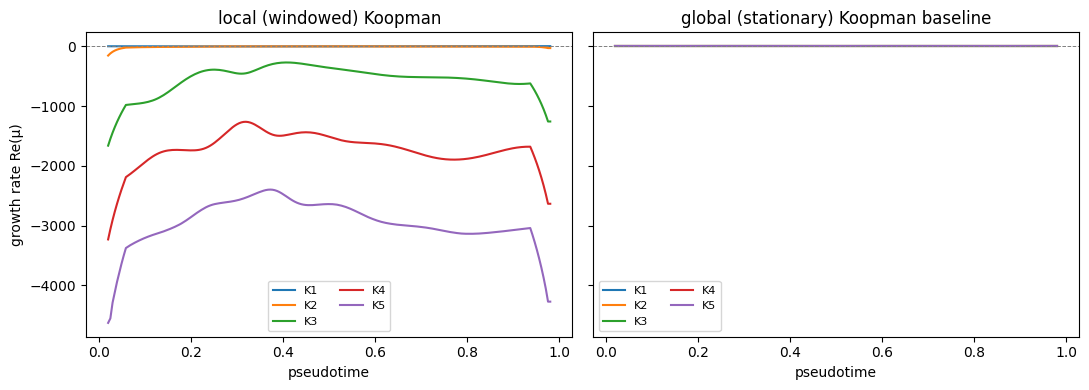

In [10]:
sjd.tl.fit_drift(
    adata,
    time_key='pseudotime',
    n_archetypes=N_ARCHETYPES,
    n_epochs=N_EPOCHS,
    vel_scale=2.0,
    archetype_method='koopman',
    koopman_kwargs=dict(mode='global', ridge=1e-4),
    key_added='scjdo_koop_global',
    verbose=False,
)

growth_local  = np.asarray(adata.uns['scjdo_koop']['koopman']['growth_rates'])
growth_global = np.asarray(adata.uns['scjdo_koop_global']['koopman']['growth_rates'])
t_local  = adata.uns['scjdo_koop']['t_centers']
t_global = adata.uns['scjdo_koop_global']['t_centers']

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for k in range(growth_local.shape[1]):
    axes[0].plot(t_local, growth_local[:, k], lw=1.5, label=f'K{k+1}')
axes[0].axhline(0, color='0.5', lw=0.7, linestyle='--')
axes[0].set_title('local (windowed) Koopman')
axes[0].set_xlabel('pseudotime')
axes[0].set_ylabel('growth rate Re(μ)')
axes[0].legend(fontsize=8, ncol=2)

for k in range(growth_global.shape[1]):
    axes[1].plot(t_global, growth_global[:, k], lw=1.5, label=f'K{k+1}')
axes[1].axhline(0, color='0.5', lw=0.7, linestyle='--')
axes[1].set_title('global (stationary) Koopman baseline')
axes[1].set_xlabel('pseudotime')
axes[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(OUTDIR + 'local_vs_global.pdf', bbox_inches='tight')
plt.show()


## 9. Save

`adata.uns['scjdo_snmf']`, `adata.uns['scjdo_koop']`, and
`adata.uns['scjdo_koop_global']` all persist through `write_h5ad`, so
the whole comparison is one file for downstream regulator inference
(`sjd.tl.infer_regulators`) or figure regeneration.


In [11]:
adata.write_h5ad(OUTDIR + 'paul15_koopman.h5ad')
print(f'Saved to {OUTDIR}paul15_koopman.h5ad')


TypeError: Can't implicitly convert non-string objects to strings

## 10. When to reach for Koopman vs semi-NMF

| Situation | Recommended backend |
|---|---|
| Report a *program* (genes, TFs, activation window) | semi-NMF |
| Report a *rate* (growth, oscillation, spectral gap) | Koopman |
| Dense time-resolved, mostly-autonomous trajectory | Koopman + semi-NMF, compared |
| Sparse atlas-like snapshot, strongly branch-heavy | semi-NMF |
| Diagnose "one dominant slow mode vs many recurrent switches" | Koopman |

Full derivation, per-window operator model, and caveats specific to
snapshot scRNA-seq: [`../KOOPMAN.md`](../KOOPMAN.md).
